In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

### Load data
traffic_data = pd.read_csv('Transformed_TGSIM_Foggy_Bottom_200sec(in).csv')

In [3]:
traffic_data = pd.DataFrame(traffic_data)
#print(traffic_data)
traffic_data.head()

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common
0,165,3700.0,183.966348,308.305096,36,0.108236,6.005233,0.018661,0.802440,15.0,2.413078,7
1,165,3700.1,183.978291,308.896475,36,0.119433,5.913793,0.111968,-0.914408,15.0,2.413078,7
2,165,3700.2,183.991354,309.478151,36,0.130630,5.816753,0.111968,-0.970392,15.0,2.413078,7
3,165,3700.3,184.004604,310.048069,36,0.132496,5.699187,0.018661,-1.175667,15.0,2.413078,7
4,165,3700.4,184.017107,310.605112,36,0.125031,5.570423,-0.074646,-1.287635,15.0,2.413078,7


In [4]:
N = 3

# Round only float columns
float_cols = traffic_data.select_dtypes(include=['float']).columns
traffic_data[float_cols] = float_cols.round(N)
traffic_data.head()

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common
0,165,time,xloc_kf,yloc_kf,36,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,7
1,165,time,xloc_kf,yloc_kf,36,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,7
2,165,time,xloc_kf,yloc_kf,36,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,7
3,165,time,xloc_kf,yloc_kf,36,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,7
4,165,time,xloc_kf,yloc_kf,36,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,7


In [5]:
traffic_data.tail()

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common
71356,19268,time,xloc_kf,yloc_kf,4,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,0
71357,19268,time,xloc_kf,yloc_kf,4,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,0
71358,19268,time,xloc_kf,yloc_kf,4,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,0
71359,19268,time,xloc_kf,yloc_kf,4,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,0
71360,19268,time,xloc_kf,yloc_kf,4,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,0


C:\Users\snoma\AppData\Local\Temp\ipykernel_24640\1982617348.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type_most_common', y='total_speed', data=df, palette='Set2')
C:\Users\snoma\AppData\Local\Temp\ipykernel_24640\1982617348.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='type_most_common', y='acceleration_kf_x', data=df, inner="quartile", palette='Pastel1')


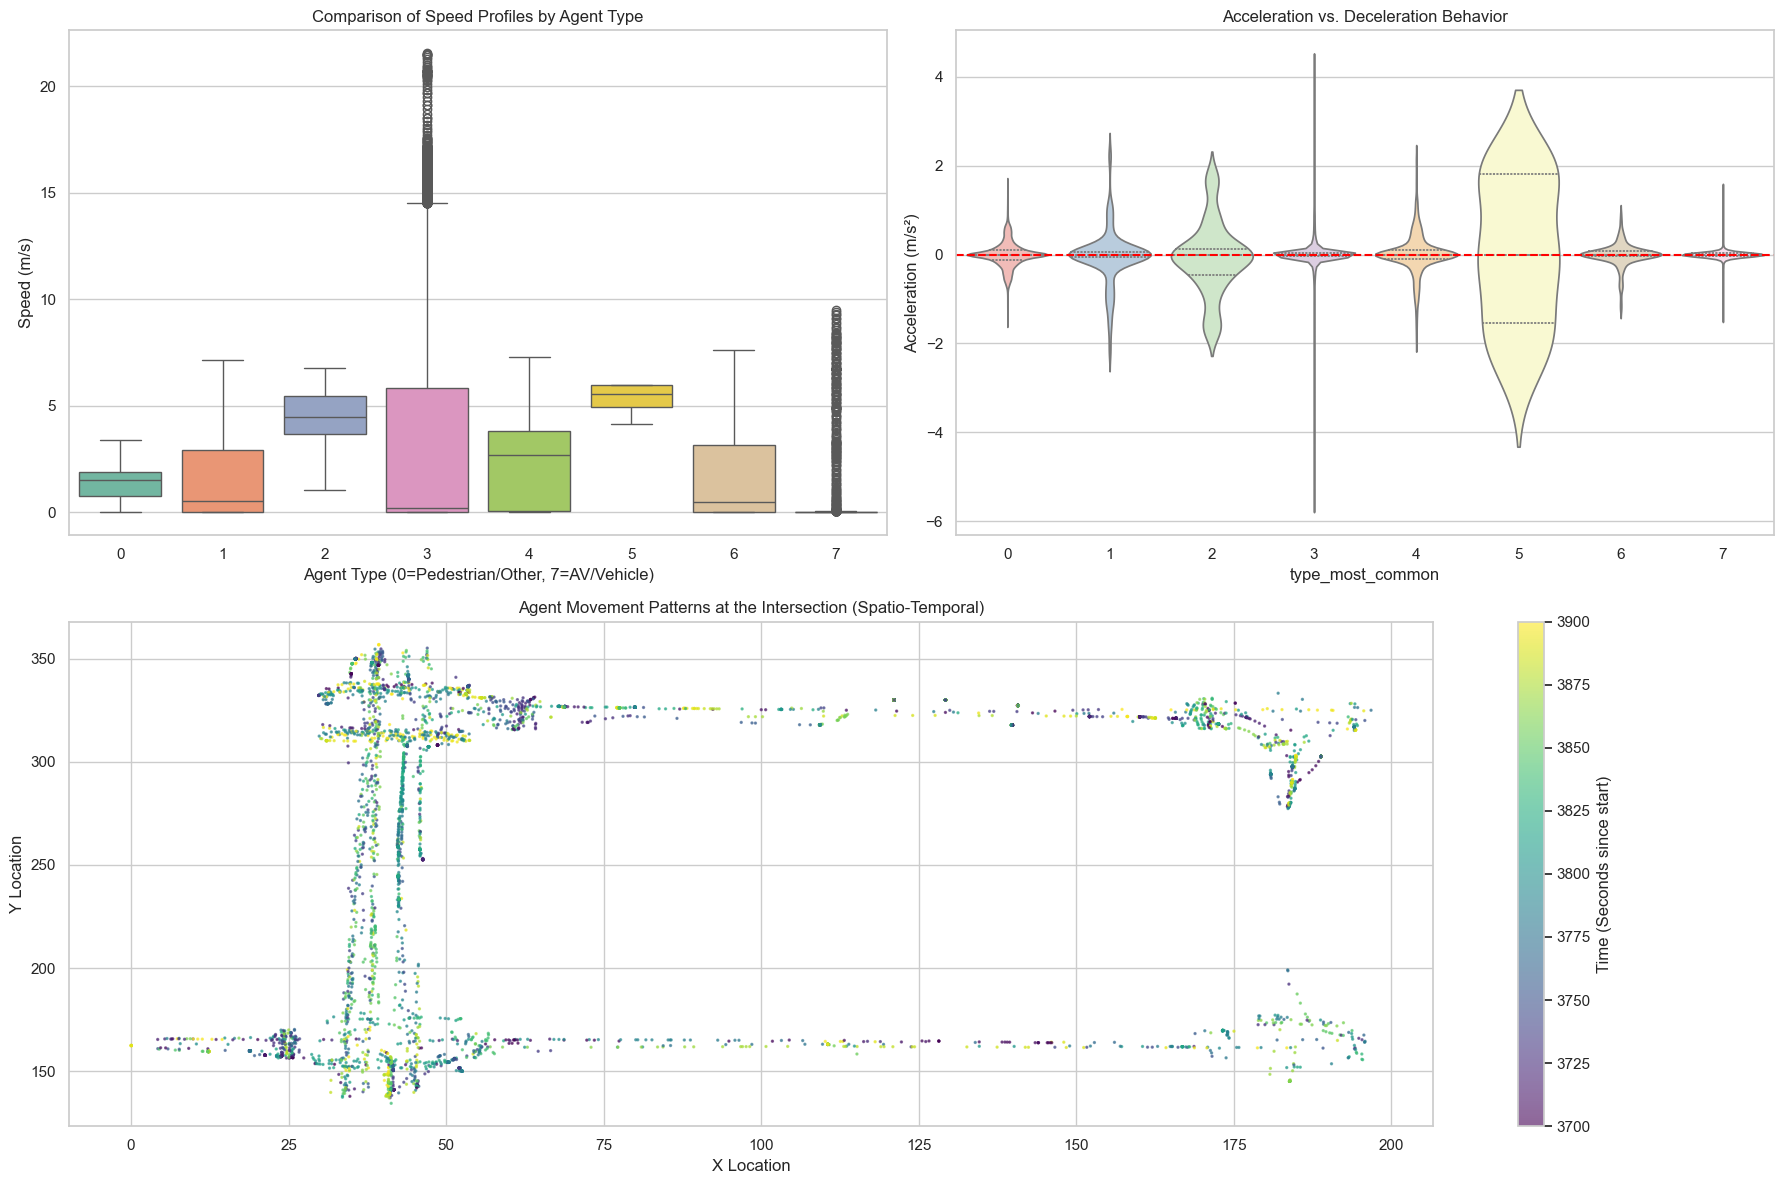

--- SUMMARY TABLE: AGENT BEHAVIOR ---
  type_most_common total_speed           acceleration_kf_x          
                          mean       std              mean       min
0                0    1.302075  0.768391         -0.000884 -1.548895
1                1    1.727159  2.088950         -0.054485 -2.258027
2                2    4.426109  1.300884         -0.083265 -1.716847
3                3    3.256133  4.832910          0.008757 -5.691722
4                4    2.470593  2.144249          0.015836 -1.978107
5                5    5.381609  0.600524         -0.000718 -2.649917
6                6    1.830558  2.445692         -0.009199 -1.268974
7                7    0.370550  1.440816         -0.008488 -1.455588


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_name = 'Transformed_TGSIM_Foggy_Bottom_200sec(in).csv'
df = pd.read_csv(file_name, skiprows=1, names=[
    'id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x', 'speed_kf_y', 
    'acceleration_kf_x', 'acceleration_kf_y', 'length_smoothed', 'width_smoothed', 'type_most_common'
])

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

# Create a 'Total Speed' column for better comparison
df['total_speed'] = np.sqrt(df['speed_kf_x']**2 + df['speed_kf_y']**2)

plt.figure(figsize=(18, 12))

# 1. Speed Profiles by Agent Type
plt.subplot(2, 2, 1)
sns.boxplot(x='type_most_common', y='total_speed', data=df, palette='Set2')
plt.title('Comparison of Speed Profiles by Agent Type')
plt.xlabel('Agent Type (0=Pedestrian/Other, 7=AV/Vehicle)')
plt.ylabel('Speed (m/s)')

# 2. Acceleration/Deceleration Patterns (Braking Events)
plt.subplot(2, 2, 2)
# We define a 'Deceleration Event' as acceleration less than -2.0
sns.violinplot(x='type_most_common', y='acceleration_kf_x', data=df, inner="quartile", palette='Pastel1')
plt.axhline(0, color='red', linestyle='--')
plt.title('Acceleration vs. Deceleration Behavior')
plt.ylabel('Acceleration (m/s²)')

# 3. Static Plot of Location vs. Time (Traffic Flow Map)
plt.subplot(2, 1, 2)
# We take a sample so the dots don't overlap too much
sample_df = df.sample(min(5000, len(df)))
scatter = plt.scatter(sample_df['xloc_kf'], sample_df['yloc_kf'], 
                      c=sample_df['time'], cmap='viridis', s=2, alpha=0.6)
plt.colorbar(scatter, label='Time (Seconds since start)')
plt.title('Agent Movement Patterns at the Intersection (Spatio-Temporal)')
plt.xlabel('X Location')
plt.ylabel('Y Location')

plt.tight_layout()
plt.show()

summary_table = df.groupby('type_most_common').agg({
    'total_speed': ['mean', 'std'],
    'acceleration_kf_x': ['mean', 'min']
}).reset_index()

print("--- SUMMARY TABLE: AGENT BEHAVIOR ---")
print(summary_table)